In [1]:
# Task 1: Load and Explore the Dataset
import pandas as pd

try:
    data = pd.read_csv("data.csv")
    print("Dataset loaded successfully.\n")
except FileNotFoundError:
    print("Error:The csv file was not found.")
    exit()
except Exception as e:
    print("An error occurred:", str(e))
    exit()

# Displaying first few rows
print("First few rows of the dataset:")
print(data.head())

Dataset loaded successfully.

First few rows of the dataset:
         Date   Product  Quantity Sold  Revenue ($)
0  2025-05-01    Laptop            4.0       4000.0
1  2025-05-01     Mouse           10.0        200.0
2  2025-05-01  Keyboard            NaN        500.0
3  2025-05-02    Laptop            NaN       2000.0
4  2025-05-02     Mouse            7.0          NaN


In [2]:
# Checking structure and missing values
print("Dataset Info:\n")
print(data.info())
print("Missing Values:")
print(data.isnull().sum())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           21 non-null     object 
 1   Product        21 non-null     object 
 2   Quantity Sold  18 non-null     float64
 3   Revenue ($)    19 non-null     float64
dtypes: float64(2), object(2)
memory usage: 804.0+ bytes
None
Missing Values:
Date             0
Product          0
Quantity Sold    3
Revenue ($)      2
dtype: int64


In [3]:
# Clean dataset (drop or fill missing values)
data.dropna(inplace=True)

In [4]:
print(data)

          Date   Product  Quantity Sold  Revenue ($)
0   2025-05-01    Laptop            4.0       4000.0
1   2025-05-01     Mouse           10.0        200.0
5   2025-05-02  Keyboard            3.0        300.0
6   2025-05-03    Laptop            3.0       3000.0
7   2025-05-03     Mouse            8.0        160.0
8   2025-05-03  Keyboard            6.0        600.0
9   2025-05-04    Laptop            5.0       5000.0
10  2025-05-04     Mouse           12.0        240.0
12  2025-05-05    Laptop            1.0       1000.0
13  2025-05-05     Mouse            6.0        120.0
14  2025-05-05  Keyboard            7.0        700.0
15  2025-05-06    Laptop            3.0       3000.0
17  2025-05-06  Keyboard            2.0        200.0
18  2025-05-07    Laptop            4.0       4000.0
19  2025-05-07     Mouse           11.0        220.0
20  2025-05-07  Keyboard            5.0        500.0


In [5]:
# Task 2: Basic Data Analysis
print(data.describe())

       Quantity Sold  Revenue ($)
count      16.000000    16.000000
mean        5.625000  1452.500000
std         3.242941  1706.065649
min         1.000000   120.000000
25%         3.000000   215.000000
50%         5.000000   550.000000
75%         7.250000  3000.000000
max        12.000000  5000.000000


In [6]:
# Grouped by Product and calculated mean for Quantity Sold and Revenue
grouped = data.groupby("Product")[["Quantity Sold", "Revenue ($)"]].mean()

print(grouped)

          Quantity Sold  Revenue ($)
Product                             
Keyboard       4.600000   460.000000
Laptop         3.333333  3333.333333
Mouse          9.400000   188.000000


In [7]:
#  patterns or interesting findings from the analysis
print("Laptops have lower quantity sold but much higher revenue per sale therefore a high-ticket item.\n")
print("Mouse is sold in higher quantities on average due to lower cost and higher demand.")


Laptops have lower quantity sold but much higher revenue per sale therefore a high-ticket item.

Mouse is sold in higher quantities on average due to lower cost and higher demand.


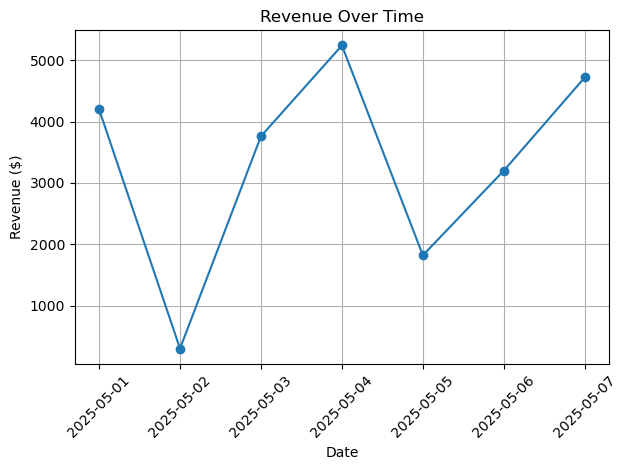

In [8]:
# Task 3: Data Visualization

import matplotlib.pyplot as plt

# 1. Line chart of revenue over time
daily_sales = data.groupby("Date")["Revenue ($)"].sum()
daily_sales.plot(kind='line', marker='o', title="Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

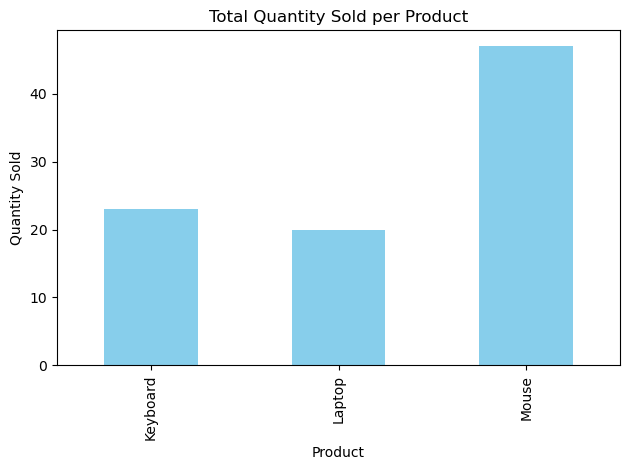

In [9]:
# 2. Bar chart: total quantity sold per product
product_sales = data.groupby("Product")["Quantity Sold"].sum()
product_sales.plot(kind='bar', color='skyblue', title="Total Quantity Sold per Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.tight_layout()
plt.show()

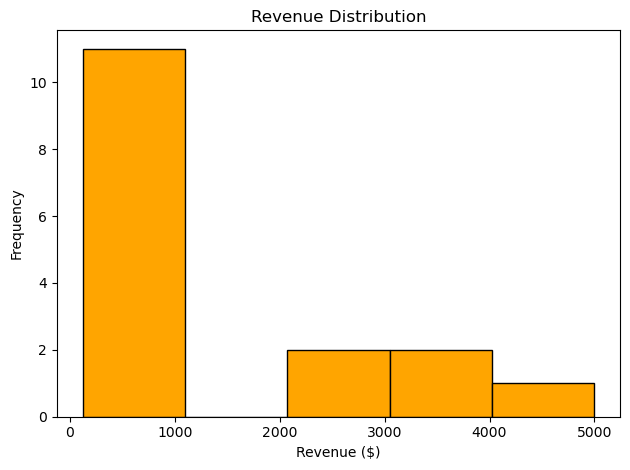

In [10]:
# 3. Histogram of revenue distribution
plt.hist(data["Revenue ($)"], bins=5, color='orange', edgecolor='black')
plt.title("Revenue Distribution")
plt.xlabel("Revenue ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

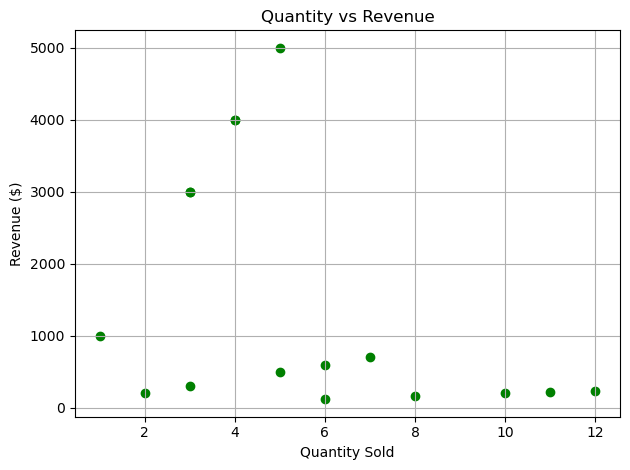

In [11]:
# 4. Scatter plot: Quantity vs Revenue
plt.scatter(data["Quantity Sold"], data["Revenue ($)"], color='green')
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity Sold")
plt.ylabel("Revenue ($)")
plt.grid(True)
plt.tight_layout()
plt.show()